# Test: anisotropic flux loss

Loads **only** selected models × timestamps via `utils/results_subset_loader.py` (not the full 6+ GB pickle every run).

**Fig_snapshots style:** `coolwarm` + saved `min`/`max` per timestamp; zoom matches Fig_snapshots panel 2.


In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = Path('notebooks') if Path('notebooks').exists() else NOTEBOOK_DIR
sys.path.insert(0, str((NOTEBOOK_DIR / '..').resolve()))

from utils.results_subset_loader import (
    fig_snapshots_color_limits,
    fig_snapshots_zoom_slice,
    index_path_for,
    load_results_index,
    load_results_subset,
)

RESULTS_FILE = (NOTEBOOK_DIR / '../outputs/Our_results_trained_models_2mT.pkl').resolve()
OUTPUT_DIR = (NOTEBOOK_DIR / '../outputs').resolve()
TARGET_VAR = '2mT'
PLOT_VAR = '2mT'
GT_MODEL = 'COSMO-CLM'  # only used when COMPUTE_FLUX_MSE=True

# ERA5 is native low-res; COSMO-CLM is high-res — skip MSE unless you upsample first
COMPUTE_FLUX_MSE = False

FORCE_REBUILD_SUBSET = False

index = load_results_index(RESULTS_FILE)
if index is not None:
    available_models = index['models']
    available_times = [pd.Timestamp(t) for t in index['time_steps']]
    print(f'Index: {index_path_for(RESULTS_FILE)} ({index["n_rows"]} rows in source)')
else:
    available_models, available_times = [], []
    print('No index yet — built on first subset-cache extraction.')

# Only check GT against index when index exists (empty index ≠ missing from pickle)
if index is not None and GT_MODEL is not None and GT_MODEL not in available_models:
    print(f'Warning: GT_MODEL={GT_MODEL!r} not in index; flux MSE may fail after load.')

if RESULTS_FILE.is_file():
    print(f'Source: {RESULTS_FILE} ({RESULTS_FILE.stat().st_size / 2**30:.2f} GiB)')

Index: C:\Users\Chuon\OneDrive\Tài liệu\GitHub\Physically-conditioned-latent-diffusion-model-for-temperature\outputs\Our_results_trained_models_2mT.index.json (4455 rows in source)
Source: C:\Users\Chuon\OneDrive\Tài liệu\GitHub\Physically-conditioned-latent-diffusion-model-for-temperature\outputs\Our_results_trained_models_2mT.pkl (6.43 GiB)


## Models, timestamps, Fig_snapshots styling


In [10]:
# Temporary: ERA5 + COSMO-CLM only (set FORCE_REBUILD_SUBSET = True once after changing this list)
SKIP_MODELS = set()  # not used when model_order is explicit

model_order = ['ERA5', 'COSMO-CLM']
exclude_models = []

time_slices = [
    '2014-04-24 02:00:00',
    '2014-12-28 03:00:00',
    '2016-05-02 04:00:00',
    '2006-05-14 10:00:00',
    '2019-09-02 02:00:00',
]
selected_times = pd.to_datetime(time_slices)

USE_FIG_SNAPSHOTS_STYLE = True
CMAP_T = 'coolwarm' if USE_FIG_SNAPSHOTS_STYLE else 'viridis'
dx, dy, grad_eps = 1.0, 1.0, 1e-6
quiver_stride_full = 50
quiver_stride_zoom = 10
# Fig_snapshots geographic zoom (EPSG:3035) — cols 2 & 4 in the 4-panel row
HR_SHAPE = (672, 576)  # COSMO / ML downscaled grid
FIG_ZOOM_XLIM = [4150000, 4450000]
FIG_ZOOM_YLIM = [1748000, 2070000]
BORDERS_FILE = (NOTEBOOK_DIR / '../LDM-downscaling/full_Dataset/plotting_resources/borders_downscaling_domain_3035.geojson').resolve()
if not BORDERS_FILE.is_file():
    BORDERS_FILE = (NOTEBOOK_DIR / '../data/plotting_resources/borders_domain_EPSG3035.geojson').resolve()
    if not BORDERS_FILE.is_file():
        BORDERS_FILE = None

def resolve_models(available, model_order=None, skip=None, exclude=None):
    skip, exclude = set(skip or []), set(exclude or [])
    models = (
        [m for m in model_order if m not in exclude and m not in skip]
        if model_order is not None
        else [m for m in sorted(available) if m not in skip and m not in exclude]
    )
    missing = [m for m in models if m not in set(available)]
    if missing:
        raise ValueError(f'Missing models: {missing}')
    if not models:
        raise ValueError('No models to plot.')
    return models

def _planned_plot_models():
    """Models we will request from the pickle (index not required)."""
    skip, exclude = set(SKIP_MODELS), set(exclude_models)
    if model_order is not None:
        return [m for m in model_order if m not in exclude and m not in skip]
    return [m for m in sorted(available_models) if m not in skip and m not in exclude]

planned = _planned_plot_models()
print('Will load from pickle:', planned)
if not available_models:
    print('(Index not built yet — model list above is from model_order; run Load subset next.)')
else:
    missing = [m for m in planned if m not in set(available_models)]
    if missing:
        print('Not in index / pickle:', missing)
    in_index = [m for m in available_models if m in set(planned)]
    display(pd.DataFrame([
        {'model': m, 'action': 'plot' if m in set(planned) else 'skip'}
        for m in available_models
    ]).sort_values(['action', 'model']))

Will load from pickle: ['ERA5', 'COSMO-CLM']


,model,action
0,COSMO-CLM,plot
1,ERA5,plot
2,GAN,skip
3,LDM_PDE_res,skip
4,LDM_res,skip
5,LMM_PDE_res,skip
6,LMM_PDE_res_020_1,skip
7,LMM_PDE_res_020_1_inv_ni,skip
8,LMM_PDE_res_020_3,skip
9,LMM_PDE_res_020_3_inv_ni,skip


## Load subset cache

First run: one full-pickle read (torch required). Later runs: fast.


In [11]:
# Use model_order directly when index is missing; subset load validates against pickle
models_to_load = _planned_plot_models()
if available_models:
    models_to_load = resolve_models(available_models, model_order, SKIP_MODELS, exclude_models)
if GT_MODEL is not None and GT_MODEL not in models_to_load:
    models_to_load = [GT_MODEL] + models_to_load

plot_df = load_results_subset(
    RESULTS_FILE,
    models=models_to_load,
    times=selected_times,
    target_var=TARGET_VAR,
    plot_var=PLOT_VAR,
    force_rebuild=FORCE_REBUILD_SUBSET,
)
models_to_plot = resolve_models(plot_df['model'].unique(), model_order, SKIP_MODELS, exclude_models)
print(f'Ready: {len(plot_df)} rows; plot models: {models_to_plot}')

Loaded subset cache (3.5 MiB, 10 rows): C:\Users\Chuon\OneDrive\Tài liệu\GitHub\Physically-conditioned-latent-diffusion-model-for-temperature\outputs\Our_results_trained_models_2mT_subset_3abf79f4b69bcbdc
Ready: 10 rows; plot models: ['ERA5', 'COSMO-CLM']


In [12]:
def as_array(value) -> np.ndarray:
    if isinstance(value, (list, tuple)) and len(value) == 1:
        value = value[0]
    if hasattr(value, 'detach'):
        value = value.detach().cpu().numpy()
    elif hasattr(value, 'values'):
        value = value.values
    arr = np.asarray(value, dtype=float).squeeze()
    if arr.ndim != 2:
        raise ValueError(f'Expected 2-D field, got shape {arr.shape}')
    return arr


def get_temperature_field(df, model: str, ts) -> np.ndarray:
    ts = pd.to_datetime(ts)
    row = df[(df['model'] == model) & (df['time_step'] == ts)]
    if row.empty:
        raise KeyError(f'No row for model={model!r}, time={ts}')
    return as_array(row.iloc[0]['spat_distr'])


def upsample_to_reference_grid(field: np.ndarray, ref_shape: tuple[int, int], label: str = '') -> np.ndarray:
    """ERA5 in the pickle is native low-res; COSMO-CLM is high-res (typically 8× per axis)."""
    if field.shape == ref_shape:
        return field
    h, w = field.shape
    rh, rw = ref_shape[0] // h, ref_shape[1] // w
    if rh * h == ref_shape[0] and rw * w == ref_shape[1]:
        return np.repeat(np.repeat(field, rh, axis=0), rw, axis=1)
    raise ValueError(
        f'Cannot align {label or "field"} shape {field.shape} to reference {ref_shape}. '
        'Expected an integer upsample factor (e.g. 8× for ERA5 → COSMO grid).'
    )


def compute_gradients(T, dx=1.0, dy=1.0):
    T = np.asarray(T, dtype=float)
    H, W = T.shape
    dTdx = np.zeros_like(T)
    dTdy = np.zeros_like(T)
    if W > 2:
        dTdx[:, 1:-1] = (T[:, 2:] - T[:, :-2]) / (2.0 * dx)
    if H > 2:
        dTdy[1:-1, :] = (T[2:, :] - T[:-2, :]) / (2.0 * dy)
    if W > 1:
        dTdx[:, 0] = (T[:, 1] - T[:, 0]) / dx
        dTdx[:, -1] = (T[:, -1] - T[:, -2]) / dx
    if H > 1:
        dTdy[0, :] = (T[1, :] - T[0, :]) / dy
        dTdy[-1, :] = (T[-1, :] - T[-2, :]) / dy
    return dTdx, dTdy


def compute_q_field(T, dx=1.0, dy=1.0, eps=1e-6):
    dTdx, dTdy = compute_gradients(T, dx=dx, dy=dy)
    grad_sq = dTdx ** 2 + dTdy ** 2
    qx = -grad_sq * dTdx
    qy = -grad_sq * dTdy
    q_mag = np.sqrt(qx ** 2 + qy ** 2 + eps)
    return qx, qy, q_mag, dTdx, dTdy


def flux_mse(q_pred_x, q_pred_y, q_gt_x, q_gt_y) -> float:
    return float(np.mean((q_pred_x - q_gt_x) ** 2 + (q_pred_y - q_gt_y) ** 2))


def validate_times(df, times):
    available_times = set(pd.to_datetime(df['time_step']))
    missing = [ts for ts in times if pd.to_datetime(ts) not in available_times]
    if missing:
        raise ValueError(f'Missing timestamps: {missing}')


def temperature_limits_for_model_timestamp(df, ts, model, variable=PLOT_VAR):
    ts = pd.to_datetime(ts)
    row = df[(df['model'] == model) & (pd.to_datetime(df['time_step']) == ts)]
    if row.empty:
        raise KeyError(f'No row for {model=} {ts=}')
    min_v, max_v = float(row.iloc[0]['min']), float(row.iloc[0]['max'])
    if min_v < 0 and max_v > 0:
        bound = max(abs(min_v), abs(max_v))
        min_v, max_v = -bound, bound
    return min_v, max_v


def target_res_for_shape(shape: tuple[int, int]) -> str:
    return 'high' if shape == HR_SHAPE else 'low'


def field_to_dataarray(field: np.ndarray, target_res: str):
    import torch
    from utils.plotting_utils import get_target_grid, from_torchtensor_to_xarray
    grid = get_target_grid(target_res)
    return from_torchtensor_to_xarray(torch.from_numpy(np.asarray(field, dtype=float)), grid, coords_name='lat_lon')

## Flux MSE vs ground truth


In [13]:
if not COMPUTE_FLUX_MSE:
    print('Skipping flux MSE (COMPUTE_FLUX_MSE=False). Visualizing q at each model native grid.')
elif GT_MODEL is None:
    print('Skipping flux MSE (GT_MODEL is None).')
else:
    validate_times(plot_df, selected_times)
    models_for_metrics = [m for m in models_to_plot if m != GT_MODEL]
    mse_rows = []
    for ts in selected_times:
        T_gt = get_temperature_field(plot_df, GT_MODEL, ts)
        ref_shape = T_gt.shape
        q_gt_x, q_gt_y, _, _, _ = compute_q_field(T_gt, dx=dx, dy=dy, eps=grad_eps)
        for model in models_for_metrics:
            T_pred = get_temperature_field(plot_df, model, ts)
            if T_pred.shape != ref_shape:
                T_pred = upsample_to_reference_grid(T_pred, ref_shape, label=model)
            qx, qy, _, _, _ = compute_q_field(T_pred, dx=dx, dy=dy, eps=grad_eps)
            mse_rows.append({'time_step': ts, 'model': model, 'flux_mse': flux_mse(qx, qy, q_gt_x, q_gt_y)})
    flux_mse_df = pd.DataFrame(mse_rows)
    display(flux_mse_df.pivot(index='model', columns='time_step', values='flux_mse'))
    display(flux_mse_df.groupby('model')['flux_mse'].mean().sort_values().to_frame('mean_flux_mse'))

Skipping flux MSE (COMPUTE_FLUX_MSE=False). Visualizing q at each model native grid.


## Plot q vectors (WS10-style: 2 columns)

Same **layout as WS10 wind** in `Fig_snapshots` / `show_snapshots`: **2 columns** (full domain | zoom), each panel = **scalar map + quiver** on lon/lat.

Difference from wind: background is **2mT [K]** (`coolwarm`, saved `min`/`max`), not WS10 jet. **q** arrows on top; length shows |q|.


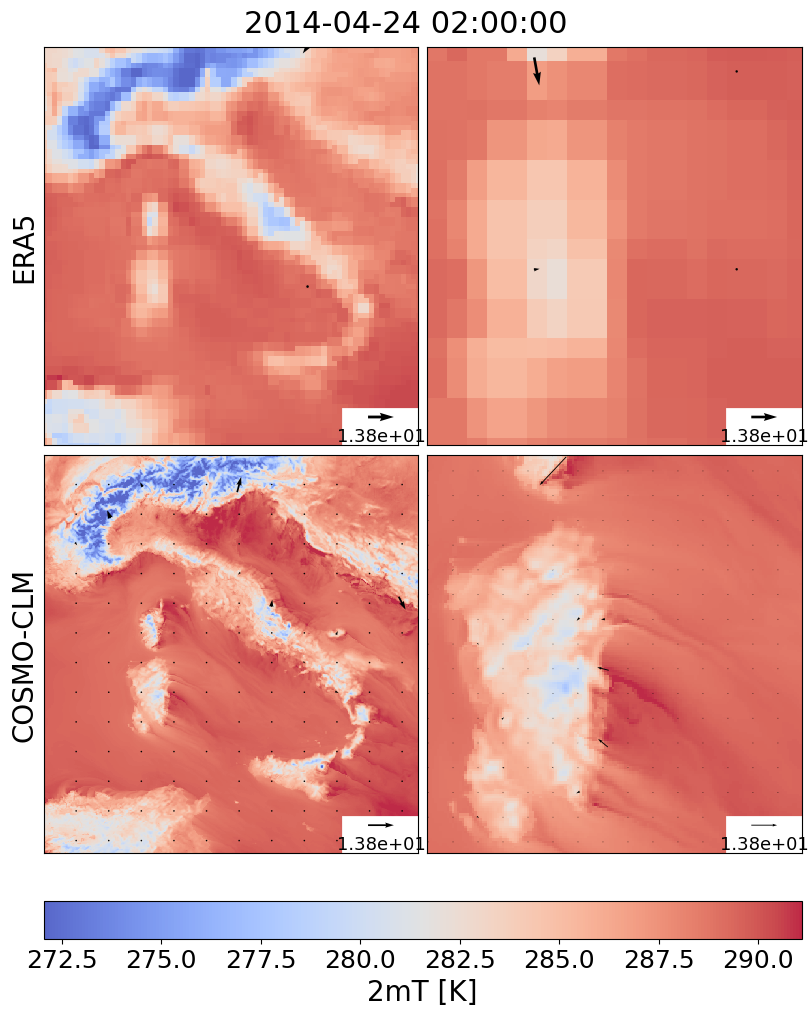

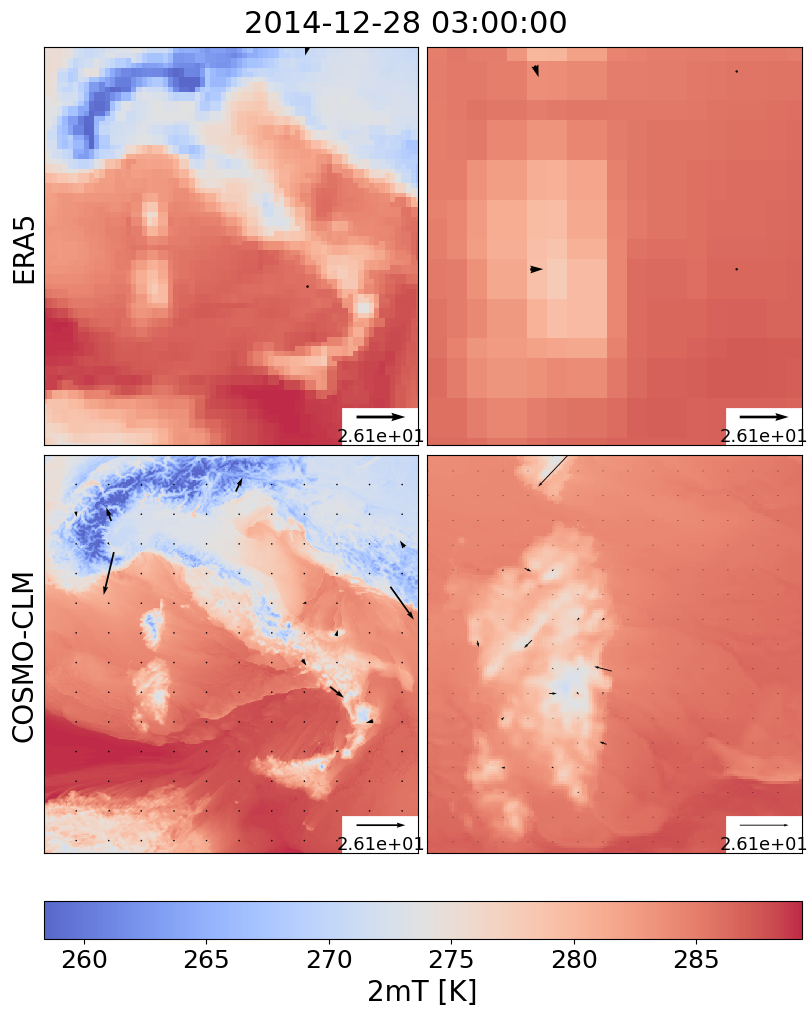

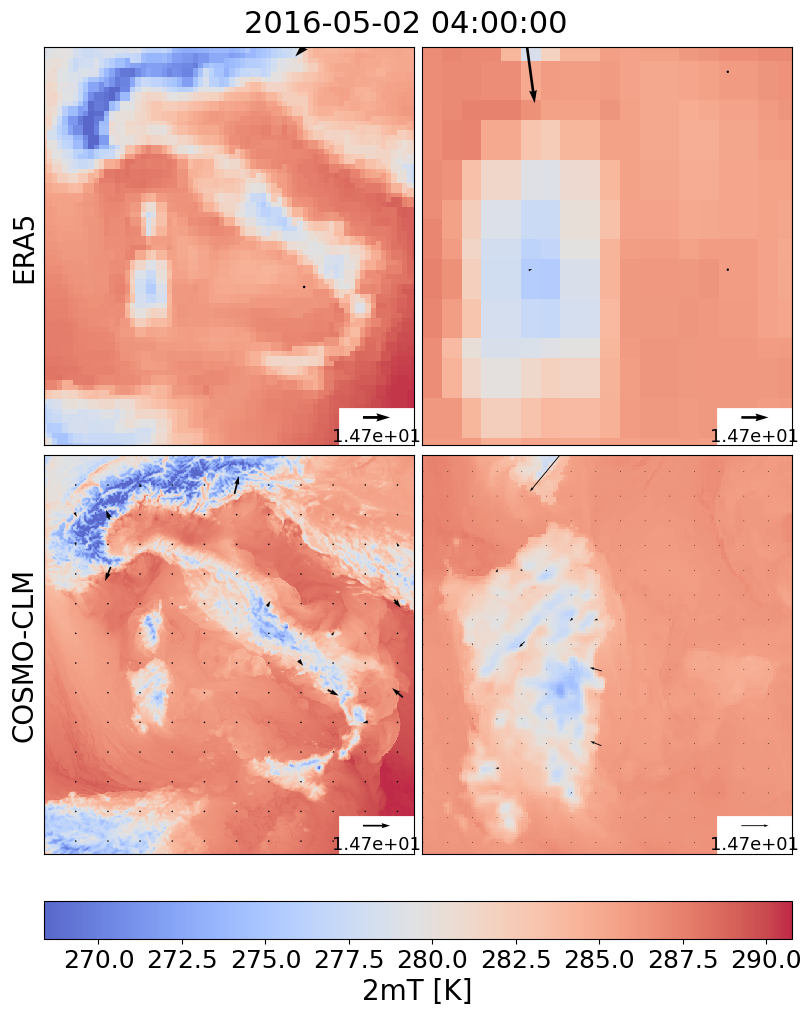

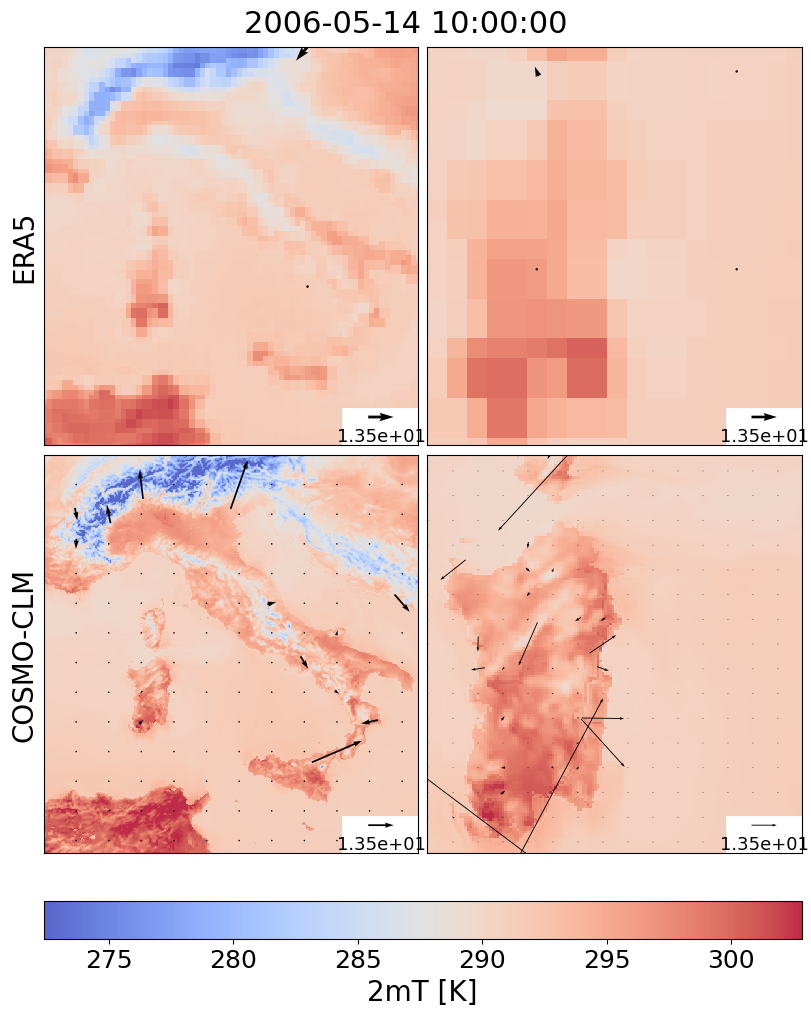

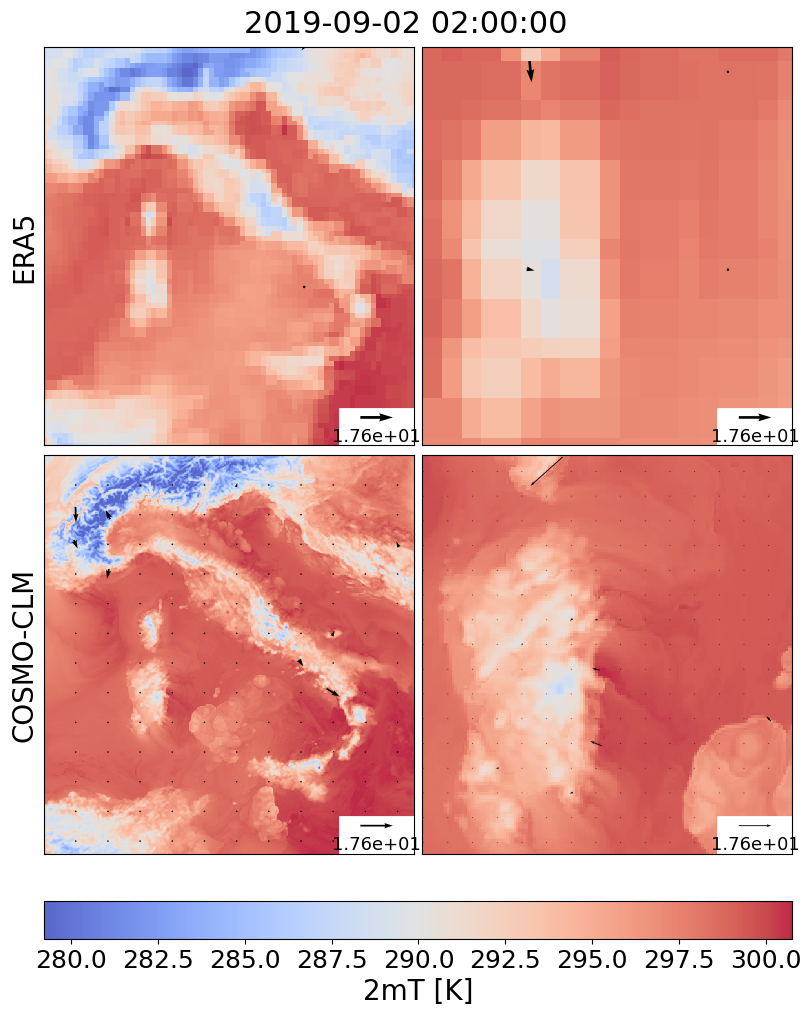

In [14]:
from utils.plotting_utils import show_temperature_flux_four_panel

for ts in selected_times:
    ts_df = plot_df[pd.to_datetime(plot_df['time_step']) == pd.to_datetime(ts)]
    show_temperature_flux_four_panel(
        ts_df,
        variable=PLOT_VAR,
        main_title=str(ts),
        borders_file=str(BORDERS_FILE) if BORDERS_FILE else None,
        output_dir=None,
        quiver_scale=200,
        pick_stride_full=quiver_stride_full,
        pick_stride_zoom=quiver_stride_zoom,
        zoom_x_lim=tuple(FIG_ZOOM_XLIM),
        zoom_y_lim=tuple(FIG_ZOOM_YLIM),
    )


In [15]:
# To save JPGs like Fig_snapshots: set output_dir=str(OUTPUT_DIR) + '/' in the cell above.


## Optional: PyTorch loss snippet


In [16]:
import torch
import torch.nn.functional as F

def anisotropic_flux_mse_loss(T_pred, T_gt, dx=1.0, dy=1.0):
    # Same q = -||grad T||^2 grad T as numpy path above
    def grad(T):
        if T.dim() == 4:
            T = T[:, 0]
        B, H, W = T.shape
        dTdx = torch.zeros_like(T)
        dTdy = torch.zeros_like(T)
        if W > 2:
            dTdx[:, :, 1:-1] = (T[:, :, 2:] - T[:, :, :-2]) / (2 * dx)
        if H > 2:
            dTdy[:, 1:-1, :] = (T[:, 2:, :] - T[:, :-2, :]) / (2 * dy)
        return dTdx, dTdy
    dTdx, dTdy = grad(T_pred)
    g2 = dTdx ** 2 + dTdy ** 2
    qx, qy = -g2 * dTdx, -g2 * dTdy
    dTdx_g, dTdy_g = grad(T_gt)
    g2g = dTdx_g ** 2 + dTdy_g ** 2
    qx_g, qy_g = -g2g * dTdx_g, -g2g * dTdy_g
    return F.mse_loss(qx, qx_g) + F.mse_loss(qy, qy_g)